# 03 · Naming phases with a classifier — trees, forests, SHAP

Once clustering has revealed the phases (notebook 02), we can **name them once**
and train a **supervised** model to label *any* new map instantly — and, crucially,
tell us *why* it decided.

You will learn:
1. a single **decision tree** (fully interpretable rules),
2. **random forests** and **gradient boosting** (accuracy + feature importance),
3. **SMOTE** for the very common problem of a **rare phase**,
4. **SHAP** values to explain individual predictions.

> No proprietary data is used: labels come from clustering the public Al–Cu map.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
rng = np.random.default_rng(0)

## 1 · Make labels (name the phases)

We cluster on `H, E` to get two phases, then *name* them by hardness: the
harder cluster is the Al₂Cu intermetallic, the softer one the Al-rich matrix.
The classifier is then trained on a **richer** feature set.

In [3]:
df = mm.load_map("alcu_2um")
lab = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(df[["H","E"]]))
# name: cluster with higher median H = intermetallic (1), else matrix (0)
hard = df.groupby(lab)["H"].median().idxmax()
y = (lab == hard).astype(int)
features = ["H","E","HE","Load","Depth"]
X = df[features].values
print("class balance:", {0:int((y==0).sum()), 1:int((y==1).sum())})

class balance: {0: 14937, 1: 25063}


## 2 · One decision tree = readable rules
A shallow tree is a flowchart you can read out loud — ideal for explaining a phase split to a colleague.

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtr, ytr)
print("test accuracy:", round(accuracy_score(yte, tree.predict(Xte)), 3))
print(export_text(tree, feature_names=features, max_depth=2))

test accuracy: 0.983
|--- Depth <= 55.64
|   |--- E <= 81.32
|   |   |--- Depth <= 53.83
|   |   |   |--- class: 1
|   |   |--- Depth >  53.83
|   |   |   |--- class: 0
|   |--- E >  81.32
|   |   |--- E <= 82.18
|   |   |   |--- class: 1
|   |   |--- E >  82.18
|   |   |   |--- class: 1
|--- Depth >  55.64
|   |--- E <= 94.78
|   |   |--- Depth <= 56.67
|   |   |   |--- class: 0
|   |   |--- Depth >  56.67
|   |   |   |--- class: 0
|   |--- E >  94.78
|   |   |--- Depth <= 73.91
|   |   |   |--- class: 1
|   |   |--- Depth >  73.91
|   |   |   |--- class: 0



## 3 · Random forest & gradient boosting
Many trees average out to a robust model, and expose which features matter.

            model  test accuracy
    decision tree          0.983
    random forest          0.998
gradient boosting          0.998


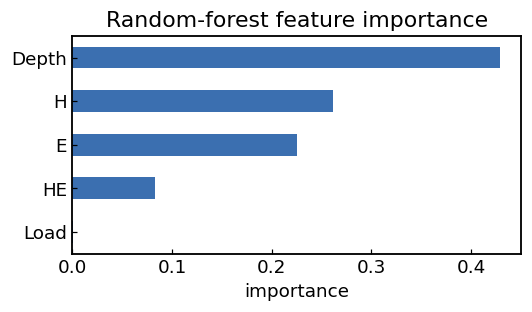

In [5]:
rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(Xtr, ytr)
gb = GradientBoostingClassifier(random_state=0).fit(Xtr, ytr)
print(pd.DataFrame({
    "model":["decision tree","random forest","gradient boosting"],
    "test accuracy":[accuracy_score(yte, m.predict(Xte)) for m in (tree, rf, gb)]
}).round(3).to_string(index=False))
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(5,3)); imp.plot.barh(ax=ax, color="#3b6fb0")
ax.set_xlabel("importance"); ax.set_title("Random-forest feature importance"); fig.tight_layout()

## 4 · The rare-phase problem, and SMOTE

Real maps often contain a phase that is only a **few percent** of indents. A
classifier trained on such data can reach high *accuracy* while **missing the
minority phase entirely**. **SMOTE** synthesises new minority examples between
real neighbours to rebalance the training set.

In [6]:
from imblearn.over_sampling import SMOTE
# force a strong imbalance: keep only 4% of the intermetallic in TRAINING
minor = np.where(ytr == 1)[0]; major = np.where(ytr == 0)[0]
keep = np.concatenate([major, rng.choice(minor, int(len(minor)*0.04), replace=False)])
Xi, yi = Xtr[keep], ytr[keep]
print("imbalanced training counts:", {0:int((yi==0).sum()), 1:int((yi==1).sum())})

rf_imb = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(Xi, yi)
Xs, ys = SMOTE(random_state=0).fit_resample(Xi, yi)
rf_smote = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(Xs, ys)

for name, m in [("no SMOTE", rf_imb), ("with SMOTE", rf_smote)]:
    r = recall_score(yte, m.predict(Xte), pos_label=1)
    print(f"{name:10s}  minority-phase recall = {r:.2f}")

imbalanced training counts: {0: 10456, 1: 701}


no SMOTE    minority-phase recall = 0.98
with SMOTE  minority-phase recall = 0.99


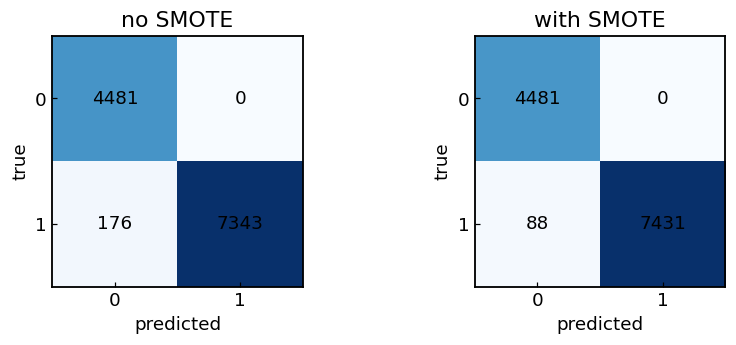

In [7]:
fig, ax = plt.subplots(1,2, figsize=(8,3.3))
for a,(name,m) in zip(ax, [("no SMOTE",rf_imb),("with SMOTE",rf_smote)]):
    cm = confusion_matrix(yte, m.predict(Xte))
    im=a.imshow(cm, cmap="Blues"); a.set_title(name)
    a.set_xticks([0,1]); a.set_yticks([0,1]); a.set_xlabel("predicted"); a.set_ylabel("true")
    for (i,j),v in np.ndenumerate(cm): a.text(j,i,f"{v}",ha="center",va="center")
fig.tight_layout()

## 5 · Why did it decide? SHAP

Feature *importance* is global. **SHAP** attributes each individual prediction
to the features that drove it, so you can defend a phase call indent-by-indent.

/sessions/busy-friendly-einstein/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


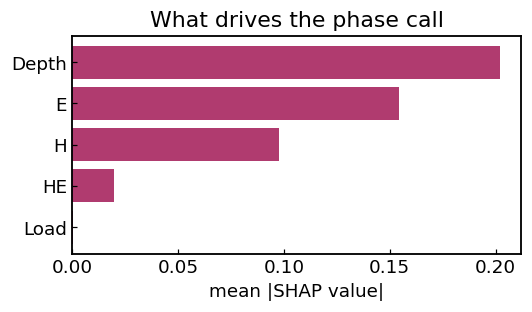

In [8]:
import shap
Xsub = Xte[rng.choice(len(Xte), 1500, replace=False)]
sv = shap.TreeExplainer(rf).shap_values(Xsub)
sv_pos = sv[1] if isinstance(sv, list) else (sv[...,1] if getattr(sv,"ndim",2)==3 else sv)
imp = np.abs(sv_pos).mean(0)
order = np.argsort(imp)
fig, ax = plt.subplots(figsize=(5,3))
ax.barh(np.array(features)[order], imp[order], color="#b03b6f")
ax.set_xlabel("mean |SHAP value|"); ax.set_title("What drives the phase call"); fig.tight_layout()

## Recap
- A shallow **decision tree** is a human-readable rule set; **forests/boosting**
  trade some interpretability for accuracy and give **feature importances**.
- A **rare phase** is the real danger — watch *recall*, not accuracy, and use
  **SMOTE** to rebalance.
- **SHAP** explains single predictions, turning the model into a testable claim.

**Next:** `04_curve_as_image_cnn.ipynb` — classify the *whole curve* with a CNN.